# 兆易创新 (603986.SH) 日线数据分析

本 Notebook 完成以下任务：
1. 从 Tushare 获取兆易创新过去一年每个交易日的日线数据
2. 绘制每日收盘价走势曲线图
3. 将数据保存为 CSV 格式

## 1. 环境配置与数据获取

In [1]:
import tushare as ts
import pandas as pd
from datetime import datetime, timedelta

# 设置 Tushare Token（请替换为你自己的 token）
TUSHARE_TOKEN = 'c3c66b1364f022a0b08660de462340a7f6713d1157e047709fa00dfb'
ts.set_token(TUSHARE_TOKEN)
pro = ts.pro_api()

print('Tushare API 已初始化')

Tushare API 已初始化


In [2]:
# 计算日期范围：过去一年
today = datetime.today()
one_year_ago = today - timedelta(days=365)
end_date = today.strftime('%Y%m%d')
start_date = one_year_ago.strftime('%Y%m%d')

print(f'查询日期范围: {start_date} ~ {end_date}')

# 获取兆易创新 (603986.SH) 日线数据
df = pro.daily(ts_code='603986.SH', start_date=start_date, end_date=end_date)

# Tushare 返回数据按日期倒序，改为正序
df = df.sort_values('trade_date').reset_index(drop=True)

print(f'获取到 {len(df)} 条日线数据')
print(f'时间范围: {df["trade_date"].iloc[0]} ~ {df["trade_date"].iloc[-1]}')

查询日期范围: 20250704 ~ 20260704
获取到 242 条日线数据
时间范围: 20250704 ~ 20260703


In [3]:
# 查看数据前5行
df.head()

,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount
0,603986.SH,20250704,119.19,120.30,117.51,118.85,119.72,-0.87,-0.7267,141826.95,1683622.173
1,603986.SH,20250707,118.98,120.81,117.86,120.81,118.85,1.96,1.6491,114584.95,1370153.527
2,603986.SH,20250708,123.00,123.50,121.01,121.71,120.81,0.90,0.7450,151877.86,1854823.191
3,603986.SH,20250709,120.91,120.99,119.29,119.47,121.71,-2.24,-1.8404,126056.42,1512241.902
4,603986.SH,20250710,119.02,119.87,118.04,118.06,119.47,-1.41,-1.1802,111583.31,1322615.181


In [4]:
# 查看数据后5行
df.tail()

,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount
237,603986.SH,20260629,779.00,846.66,750.00,840.00,770.00,70.00,9.0909,541208.83,4.314993e+07
238,603986.SH,20260630,810.00,833.00,781.11,815.00,840.00,-25.00,-2.9762,449646.79,3.639935e+07
239,603986.SH,20260701,803.00,843.38,753.00,772.01,815.00,-42.99,-5.2748,539702.17,4.320285e+07
240,603986.SH,20260702,721.00,731.99,694.81,694.81,772.01,-77.20,-9.9999,452436.41,3.212068e+07
241,603986.SH,20260703,672.54,717.66,642.35,677.77,694.81,-17.04,-2.4525,623522.15,4.267373e+07


In [5]:
# 数据基本统计
df.describe()

,open,high,low,close,pre_close,change,pct_chg,vol,amount
count,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,2.420000e+02
mean,269.660868,278.981736,262.808760,271.686983,269.377893,2.309091,0.812210,378020.552521,1.114115e+07
std,138.128551,145.661051,132.907024,141.375836,139.254574,16.424257,4.342443,153395.599716,8.939906e+06
min,114.050000,116.400000,113.820000,114.240000,114.240000,-77.200000,-10.000600,111583.310000,1.322615e+06
25%,194.382500,201.035000,186.822500,194.305000,191.722500,-5.285000,-2.267675,262289.775000,5.763574e+06
50%,233.750000,245.095000,228.390000,236.890000,233.840000,0.910000,0.424000,369886.230000,8.803434e+06
75%,301.392500,309.927500,294.502500,303.375000,302.797500,7.125000,3.271800,471291.882500,1.275892e+07
max,810.000000,846.660000,781.110000,840.000000,840.000000,70.120000,10.002900,858971.490000,4.320285e+07


## 2. 绘制收盘价走势曲线图

In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 设置中文字体（macOS 兼容）
plt.rcParams['font.family'] = ['PingFang SC', 'Heiti TC', 'Arial Unicode MS', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

# 将 trade_date 转换为 datetime 类型以便绘图
df['date'] = pd.to_datetime(df['trade_date'], format='%Y%m%d')

dates = df['date']
close_prices = df['close']
pct_changes = df['pct_chg']

findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Font family 'PingFang SC' not found.
findfont: Fon

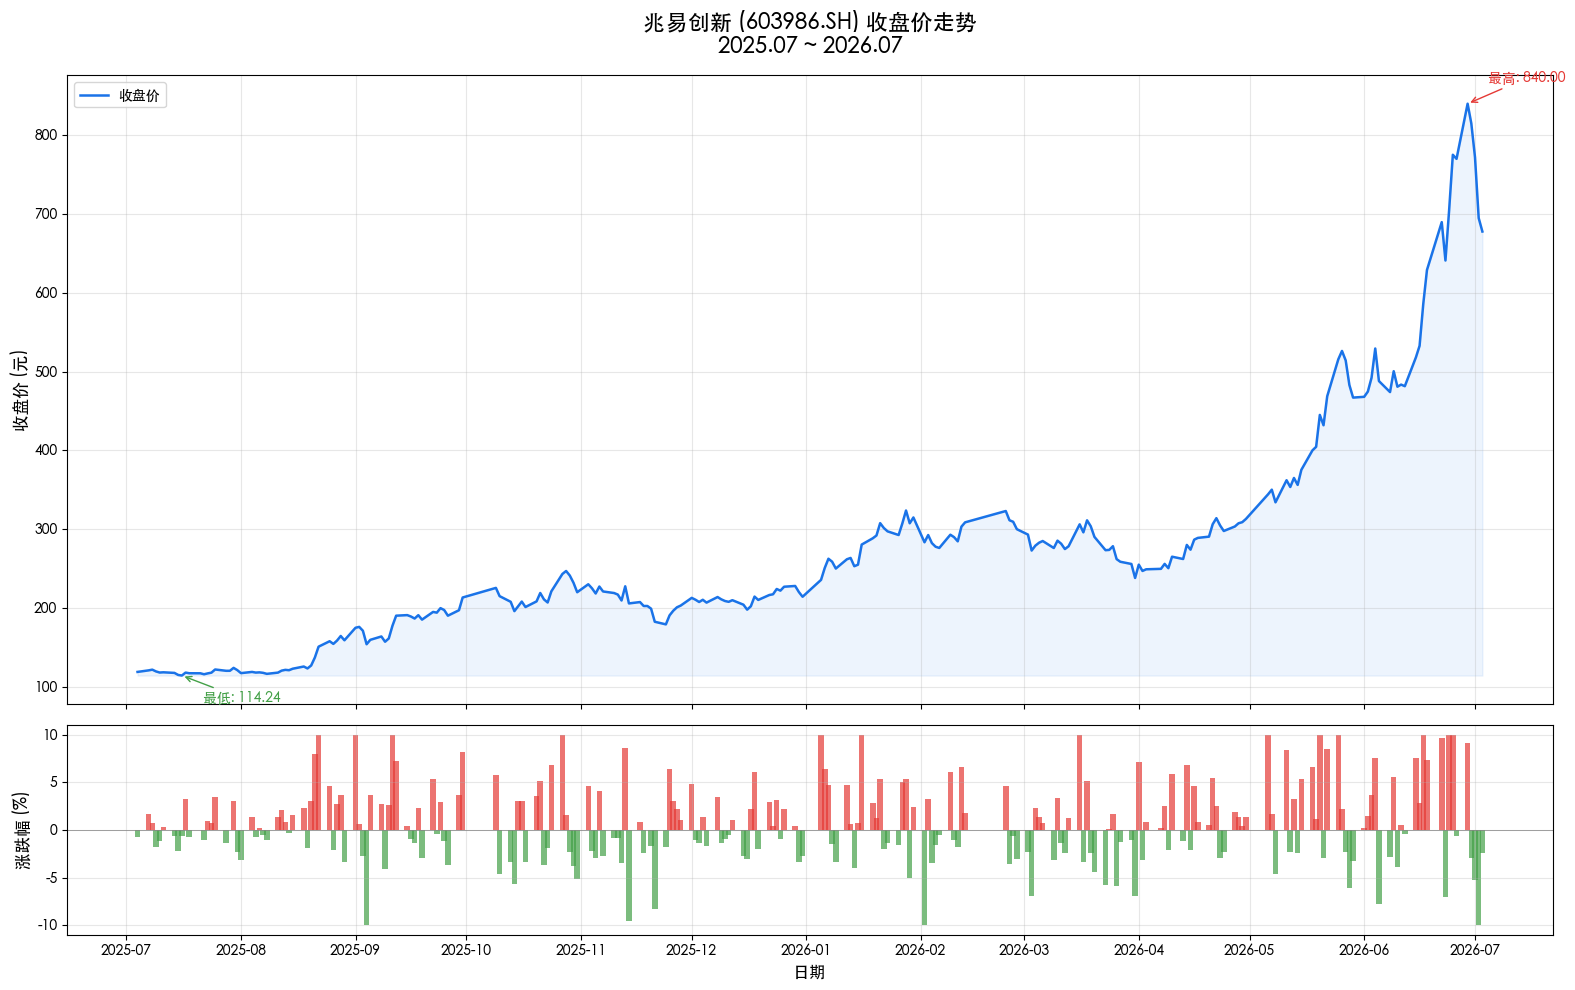

In [7]:
# === 双面板图：收盘价曲线 + 涨跌幅柱状图 ===
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10),
                                gridspec_kw={'height_ratios': [3, 1]},
                                sharex=True)

# --- 收盘价曲线 ---
ax1.plot(dates, close_prices, color='#1a73e8', linewidth=1.8, label='收盘价')
ax1.fill_between(dates, close_prices, close_prices.min(), alpha=0.08, color='#1a73e8')

# 标注最高点和最低点
max_idx = close_prices.idxmax()
min_idx = close_prices.idxmin()

ax1.annotate(f'最高: {close_prices.max():.2f}',
             xy=(dates.iloc[max_idx], close_prices.max()),
             xytext=(15, 15), textcoords='offset points', fontsize=10,
             color='#e53935', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#e53935'))
ax1.annotate(f'最低: {close_prices.min():.2f}',
             xy=(dates.iloc[min_idx], close_prices.min()),
             xytext=(15, -20), textcoords='offset points', fontsize=10,
             color='#43a047', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#43a047'))

ax1.set_title('兆易创新 (603986.SH) 收盘价走势\n2025.07 ~ 2026.07',
              fontsize=16, fontweight='bold', pad=15)
ax1.set_ylabel('收盘价 (元)', fontsize=12)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator())

# --- 涨跌幅柱状图（红涨绿跌，遵循中国股市惯例） ---
colors = ['#e53935' if p > 0 else '#43a047' for p in pct_changes]
ax2.bar(dates, pct_changes, width=1.5, color=colors, alpha=0.7)
ax2.set_ylabel('涨跌幅 (%)', fontsize=12)
ax2.set_xlabel('日期', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='gray', linewidth=0.5)

plt.tight_layout()
plt.show()

In [8]:
# 数据统计摘要
print(f'=== 数据统计 ===')
print(f'时间范围: {df["trade_date"].iloc[0]} ~ {df["trade_date"].iloc[-1]}')
print(f'数据条数: {len(df)}')
print(f'收盘价最高: {close_prices.max():.2f} ({df["trade_date"].iloc[max_idx]})')
print(f'收盘价最低: {close_prices.min():.2f} ({df["trade_date"].iloc[min_idx]})')
print(f'期初收盘价: {close_prices.iloc[0]:.2f}')
print(f'期末收盘价: {close_prices.iloc[-1]:.2f}')
pct_total = (close_prices.iloc[-1] / close_prices.iloc[0] - 1) * 100
print(f'区间涨幅: {pct_total:.2f}%')

=== 数据统计 ===
时间范围: 20250704 ~ 20260703
数据条数: 242
收盘价最高: 840.00 (20260629)
收盘价最低: 114.24 (20250716)
期初收盘价: 118.85
期末收盘价: 677.77
区间涨幅: 470.27%


## 3. 保存数据为 CSV 格式

In [9]:
# 保存为 CSV（去掉辅助列 date，只保留原始字段）
csv_cols = ['ts_code', 'trade_date', 'open', 'high', 'low', 'close',
            'pre_close', 'change', 'pct_chg', 'vol', 'amount']

csv_path = 'outputs/兆易创新_603986日线数据.csv'
df[csv_cols].to_csv(csv_path, index=False, encoding='utf-8-sig')

print(f'CSV 已保存: {csv_path}')
print(f'共 {len(df)} 条数据')

CSV 已保存: outputs/兆易创新_603986日线数据.csv
共 242 条数据


In [10]:
# 验证：读取 CSV 文件并显示前几行
pd.read_csv(csv_path).head()

,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount
0,603986.SH,20250704,119.19,120.30,117.51,118.85,119.72,-0.87,-0.7267,141826.95,1683622.173
1,603986.SH,20250707,118.98,120.81,117.86,120.81,118.85,1.96,1.6491,114584.95,1370153.527
2,603986.SH,20250708,123.00,123.50,121.01,121.71,120.81,0.90,0.7450,151877.86,1854823.191
3,603986.SH,20250709,120.91,120.99,119.29,119.47,121.71,-2.24,-1.8404,126056.42,1512241.902
4,603986.SH,20250710,119.02,119.87,118.04,118.06,119.47,-1.41,-1.1802,111583.31,1322615.181
